In [ ]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Define global color variables for plotting
DARK = '#0e1117'
C3 = ['#ff6f61', '#ffc107', '#4CAF50']

In [ ]:
DATA_PATH = "../student_mental_health_burnout.csv"

ORDINAL_MAPS = {
    "stress_level":     {"Low": 0, "Medium": 1, "High": 2},
    "sleep_quality":    {"Poor": 0, "Average": 1, "Good": 2},
    "internet_quality": {"Poor": 0, "Average": 1, "Good": 2},
    "year":             {"1st": 1, "2nd": 2, "3rd": 3, "4th": 4},
}

TARGET_MAP     = {"Low": 0, "Medium": 1, "High": 2}
TARGET_MAP_INV = {0: "Low", 1: "Medium", 2: "High"}
LABELS         = ["Low", "Medium", "High"]

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML_GDG/Student Burnout Predictor App/student_mental_health_burnout.csv')

print(f"Shape        : {df.shape}")
print(f"Missing vals : {df.isnull().sum().sum()}")
df.head()

Shape        : (150000, 20)
Missing vals : 0


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [ ]:
df2 = df.copy()

# Encode ordinals needed for scoring
df2["stress_num"]  = df2["stress_level"].map(ORDINAL_MAPS["stress_level"])
df2["sleep_q_num"] = df2["sleep_quality"].map(ORDINAL_MAPS["sleep_quality"])

# Composite burnout score
df2["burnout_score"] = (
      df2["anxiety_score"]             * 1.8
    + df2["depression_score"]          * 1.8
    + df2["academic_pressure_score"]   * 1.5
    + df2["stress_num"]                * 4.0
    + df2["financial_stress_score"]    * 0.9
    + df2["screen_time_hours"]         * 0.6
    + (10 - df2["social_support_score"]) * 0.9
    + (10 - df2["cgpa"])                 * 0.6
    + (2  - df2["sleep_q_num"])          * 2.5
    - df2["daily_sleep_hours"]           * 1.0
    - df2["physical_activity_hours"]     * 1.2
    + df2["daily_study_hours"]           * 0.4
    + (100 - df2["attendance_percentage"]) * 0.05
)

# Tertile split → balanced classes
q33 = df2["burnout_score"].quantile(0.333)
q66 = df2["burnout_score"].quantile(0.666)

df2["burnout_label"] = pd.cut(
    df2["burnout_score"],
    bins=[-np.inf, q33, q66, np.inf],
    labels=["Low", "Medium", "High"],
)
df2["target"] = df2["burnout_label"].map(TARGET_MAP)

print(f"Score thresholds:  Low ≤ {q33:.2f}  |  Medium ≤ {q66:.2f}")
print(f"\nLabel distribution:")
print(df2["burnout_label"].value_counts().sort_index())

Score thresholds:  Low ≤ 40.35  |  Medium ≤ 49.58

Label distribution:
burnout_label
Low       49950
Medium    49950
High      50100
Name: count, dtype: int64


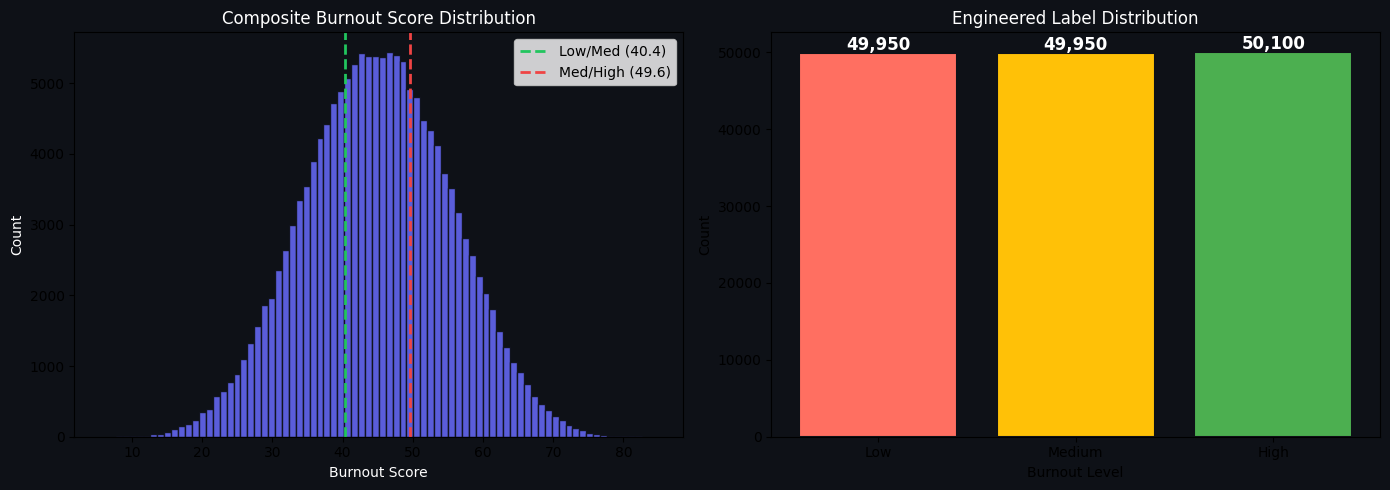

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK)
for ax in axes: ax.set_facecolor(DARK)

axes[0].hist(df2['burnout_score'], bins=80, color='#6366f1', edgecolor=DARK, alpha=0.9)
axes[0].axvline(q33, color='#22c55e', ls='--', lw=2, label=f'Low/Med ({q33:.1f})')
axes[0].axvline(q66, color='#ef4444', ls='--', lw=2, label=f'Med/High ({q66:.1f})')
axes[0].set_title('Composite Burnout Score Distribution', color='white')
axes[0].set_xlabel('Burnout Score', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].legend()

counts = df2['burnout_label'].value_counts().reindex(['Low','Medium','High'])
bars = axes[1].bar(counts.index, counts.values, color=C3, edgecolor=DARK, linewidth=1.5)
for b, v in zip(bars, counts.values):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+300,
                 f'{v:,}', ha='center', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('Engineered Label Distribution', color='white')
axes[1].set_xlabel('Burnout Level'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_new_labels.png', dpi=140, bbox_inches='tight', facecolor=DARK)
plt.show()

In [ ]:
df_ml = df2.copy()

# Encode nominal columns
for col in ["gender", "course"]:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

# Map remaining ordinals
df_ml["stress_level"]    = df_ml["stress_num"]
df_ml["sleep_quality"]   = df_ml["sleep_q_num"]
df_ml["internet_quality"] = df_ml["internet_quality"].map(ORDINAL_MAPS["internet_quality"])
df_ml["year"]            = df_ml["year"].map(ORDINAL_MAPS["year"])

# ── 12 engineered features ───────────────────────────────────────────────────
df_ml["mental_composite"]      = df_ml["anxiety_score"] + df_ml["depression_score"] + df_ml["stress_level"] * 2
df_ml["stress_resilience"]     = df_ml["social_support_score"] / (df_ml["stress_level"] + 1)
df_ml["sleep_deficit"]         = (8.0 - df_ml["daily_sleep_hours"]).clip(lower=0)
df_ml["study_overload"]        = df_ml["daily_study_hours"] / (df_ml["daily_sleep_hours"] + 0.5)
df_ml["academic_mental_cross"] = df_ml["academic_pressure_score"] * df_ml["depression_score"]
df_ml["recovery_index"]        = df_ml["physical_activity_hours"] * 2 + df_ml["daily_sleep_hours"] + df_ml["social_support_score"] * 0.5
df_ml["burnout_risk_raw"]      = df_ml["anxiety_score"] + df_ml["depression_score"] + df_ml["academic_pressure_score"]
df_ml["financial_mental"]      = df_ml["financial_stress_score"] * df_ml["anxiety_score"]
df_ml["screen_to_sleep"]       = df_ml["screen_time_hours"] / (df_ml["daily_sleep_hours"] + 0.1)
df_ml["cgpa_efficiency"]       = df_ml["cgpa"] / (df_ml["daily_study_hours"] + 0.5)
df_ml["total_stress_burden"]   = df_ml["academic_pressure_score"] + df_ml["financial_stress_score"] + df_ml["stress_level"] * 3
df_ml["wellbeing_gap"]         = df_ml["mental_composite"] - df_ml["recovery_index"]

# ── Prepare X / y ─────────────────────────────────────────────────────────────
DROP = ["student_id", "burnout_level", "burnout_score", "burnout_label",
        "target", "stress_num", "sleep_q_num"]

X = df_ml.drop(columns=[c for c in DROP if c in df_ml.columns])
y = df_ml["target"]
FEATURE_COLS = list(X.columns)

print(f"Total features : {len(FEATURE_COLS)}  (19 raw + 12 engineered - dropped helpers)")
print(f"Samples        : {len(X):,}")

Total features : 30  (19 raw + 12 engineered - dropped helpers)
Samples        : 150,000


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")


Train : (105000, 30)
Val   : (22500, 30)
Test  : (22500, 30)


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_features="sqrt",
        n_jobs=-1, random_state=42,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, max_features="sqrt",
        n_jobs=-1, random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.08, max_depth=8,
        subsample=0.85, colsample_bytree=0.85,
        gamma=0.05, reg_alpha=0.1, reg_lambda=1.0,
        eval_metric="mlogloss", n_jobs=-1,
        random_state=42, verbosity=0,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.08, num_leaves=95,
        subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.5,
        n_jobs=-1, random_state=42, verbose=-1,
    ),
    "Logistic Regression": LogisticRegression(
        C=5.0, max_iter=2000, solver="lbfgs",
        n_jobs=-1, random_state=42,
    ),
}



In [ ]:
results = {}
trained = {}

for name, model in models.items():
    t0         = time.time()
    use_scaled = name == "Logistic Regression"
    Xtr        = X_train_sc if use_scaled else X_train
    Xvl        = X_val_sc   if use_scaled else X_val

    model.fit(Xtr, y_train)
    preds = model.predict(Xvl)

    results[name] = {
        "Accuracy":    round(accuracy_score(y_val, preds), 6),
        "F1 Weighted": round(f1_score(y_val, preds, average="weighted"), 6),
        "F1 Macro":    round(f1_score(y_val, preds, average="macro"), 6),
        "Time (s)":    round(time.time() - t0, 1),
    }
    trained[name] = model
    print(f"  {name:<22}  acc={results[name]['Accuracy']:.4f}  "
          f"f1w={results[name]['F1 Weighted']:.4f}  [{results[name]['Time (s)']}s]")

print("\n Validation Leaderboard:")
pd.DataFrame(results).T.sort_values("F1 Weighted", ascending=False)

  Random Forest           acc=0.9203  f1w=0.9208  [90.7s]
  Extra Trees             acc=0.9212  f1w=0.9216  [52.9s]
  XGBoost                 acc=0.9705  f1w=0.9706  [34.9s]
  LightGBM                acc=0.9726  f1w=0.9727  [37.4s]
  Logistic Regression     acc=0.9992  f1w=0.9992  [4.7s]

 Validation Leaderboard:


,Accuracy,F1 Weighted,F1 Macro,Time (s)
Logistic Regression,0.999156,0.999156,0.999155,4.7
LightGBM,0.972622,0.972686,0.972677,37.4
XGBoost,0.970533,0.970623,0.970615,34.9
Extra Trees,0.921156,0.921586,0.921567,52.9
Random Forest,0.920311,0.920779,0.920761,90.7


In [ ]:
top3 = (
    pd.DataFrame(results).T
    .sort_values("F1 Weighted", ascending=False)
    .index[:3]
    .tolist()
)
print("Ensemble members:", top3)

estimators = [(n.replace(" ", "_"), trained[n]) for n in top3]
ensemble   = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)

t0    = time.time()
ensemble.fit(X_train, y_train)
preds = ensemble.predict(X_val)

results["Voting Ensemble"] = {
    "Accuracy":    round(accuracy_score(y_val, preds), 6),
    "F1 Weighted": round(f1_score(y_val, preds, average="weighted"), 6),
    "F1 Macro":    round(f1_score(y_val, preds, average="macro"), 6),
    "Time (s)":    round(time.time() - t0, 1),
}
trained["Voting Ensemble"] = ensemble

print(f"\n Ensemble → acc={results['Voting Ensemble']['Accuracy']:.4f}  "
      f"f1w={results['Voting Ensemble']['F1 Weighted']:.4f}")

print("\nFinal Leaderboard:")
pd.DataFrame(results).T.sort_values("F1 Weighted", ascending=False)

Ensemble members: ['Logistic Regression', 'LightGBM', 'XGBoost']

 Ensemble → acc=0.9827  f1w=0.9827

Final Leaderboard:


,Accuracy,F1 Weighted,F1 Macro,Time (s)
Logistic Regression,0.999156,0.999156,0.999155,4.7
Voting Ensemble,0.982667,0.982694,0.982690,172.4
LightGBM,0.972622,0.972686,0.972677,37.4
XGBoost,0.970533,0.970623,0.970615,34.9
Extra Trees,0.921156,0.921586,0.921567,52.9
Random Forest,0.920311,0.920779,0.920761,90.7


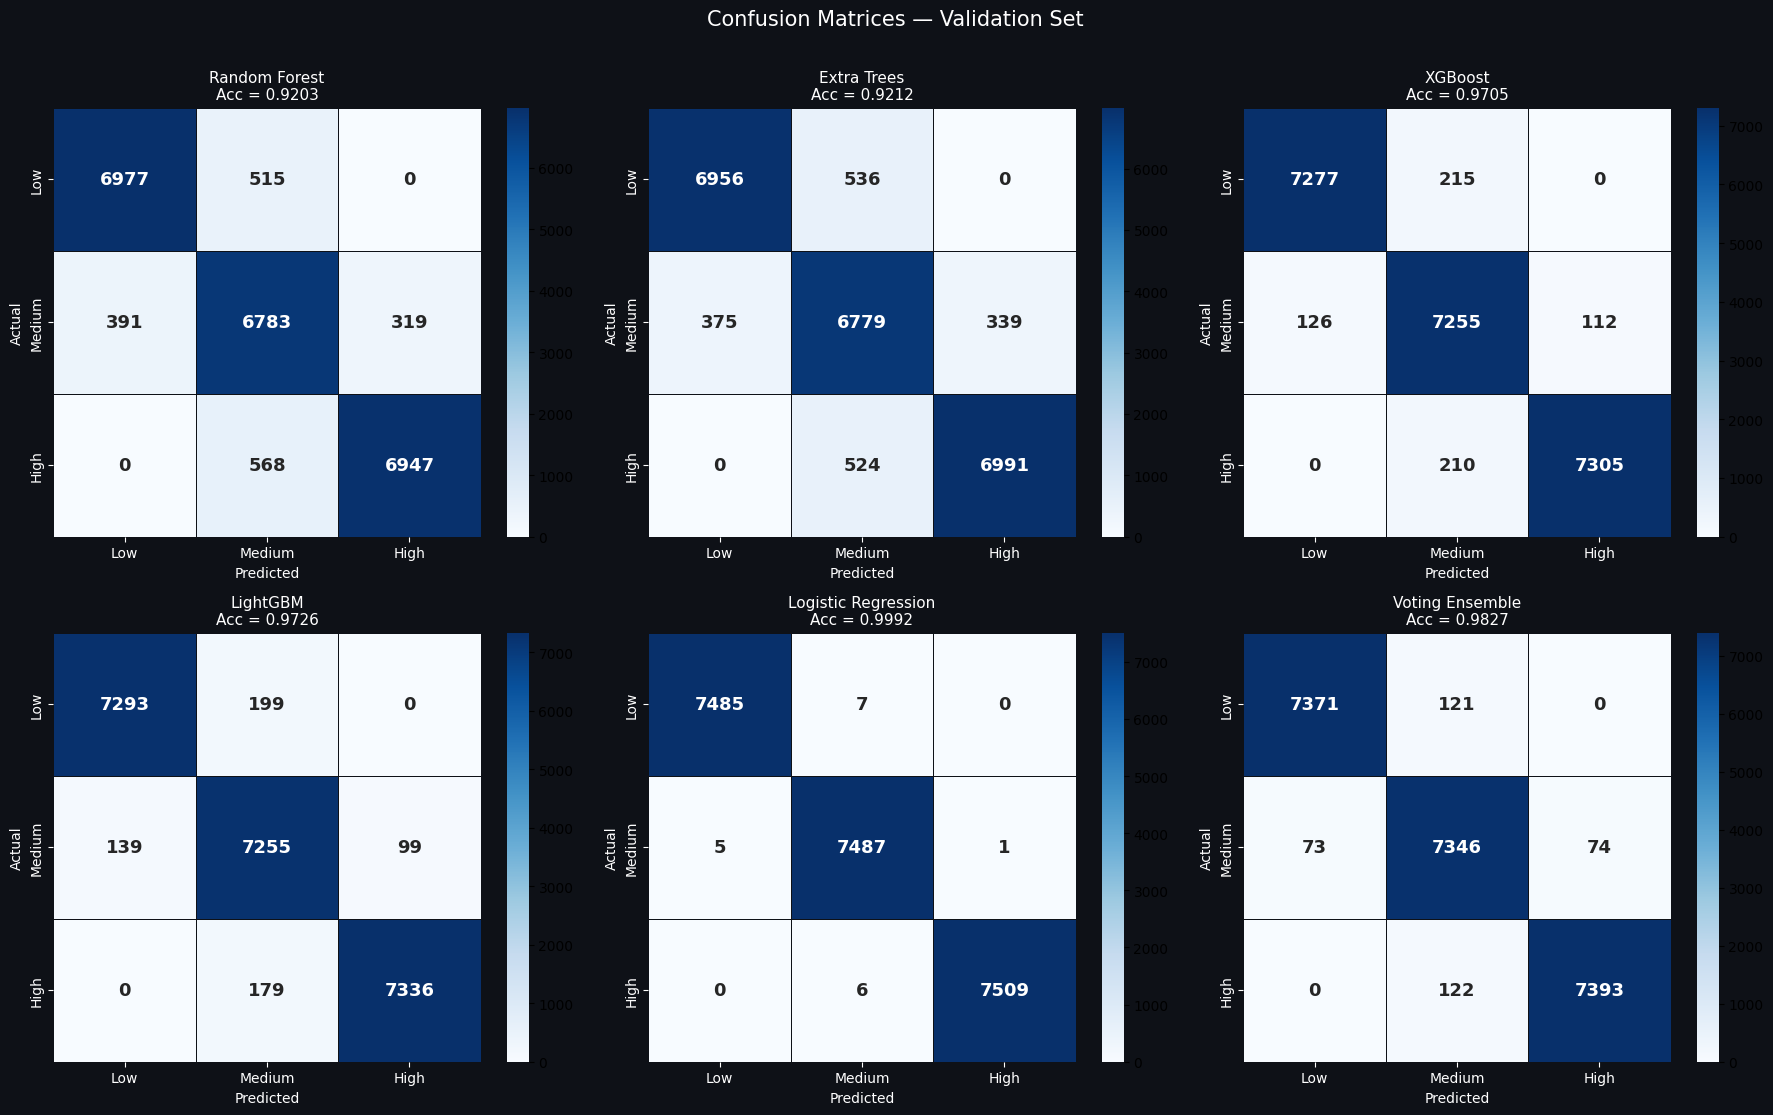

In [ ]:
n_models = len(trained)
cols = 3; rows = (n_models + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows*5+1))
fig.patch.set_facecolor(DARK)
axes_flat = axes.flatten()

for idx, (name, model) in enumerate(trained.items()):
    ax = axes_flat[idx]
    ax.set_facecolor(DARK)
    preds = model.predict(X_val_sc if name=='Logistic Regression' else X_val)
    cm  = confusion_matrix(y_val, preds)
    acc = accuracy_score(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS,
                ax=ax, linewidths=.5, linecolor=DARK,
                annot_kws={'size':13,'weight':'bold'})
    ax.set_title(f'{name}\nAcc = {acc:.4f}', color='white', fontsize=11)
    ax.set_xlabel('Predicted', color='white'); ax.set_ylabel('Actual', color='white')
    ax.tick_params(colors='white')

for ax in axes_flat[n_models:]: ax.set_visible(False)
plt.suptitle('Confusion Matrices — Validation Set', color='white', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=140, bbox_inches='tight', facecolor=DARK)
plt.show()

In [ ]:
best_name  = max(results, key=lambda k: results[k]["F1 Weighted"])
best_model = trained[best_name]

X_te  = X_test_sc if best_name == "Logistic Regression" else X_test
preds = best_model.predict(X_te)

test_acc = accuracy_score(y_test, preds)
test_f1w = f1_score(y_test, preds, average="weighted")
test_f1m = f1_score(y_test, preds, average="macro")

print(f" Best Model   : {best_name}")
print(f"   Accuracy      : {test_acc:.4f}")
print(f"   F1 Weighted   : {test_f1w:.4f}")
print(f"   F1 Macro      : {test_f1m:.4f}")
print("\n Classification Report:")
print(classification_report(y_test, preds, target_names=LABELS, digits=4))



 Best Model   : Logistic Regression
   Accuracy      : 0.9990
   F1 Weighted   : 0.9990
   F1 Macro      : 0.9990

 Classification Report:
              precision    recall  f1-score   support

         Low     0.9997    0.9987    0.9992      7493
      Medium     0.9983    0.9988    0.9985      7492
        High     0.9991    0.9996    0.9993      7515

    accuracy                         0.9990     22500
   macro avg     0.9990    0.9990    0.9990     22500
weighted avg     0.9990    0.9990    0.9990     22500



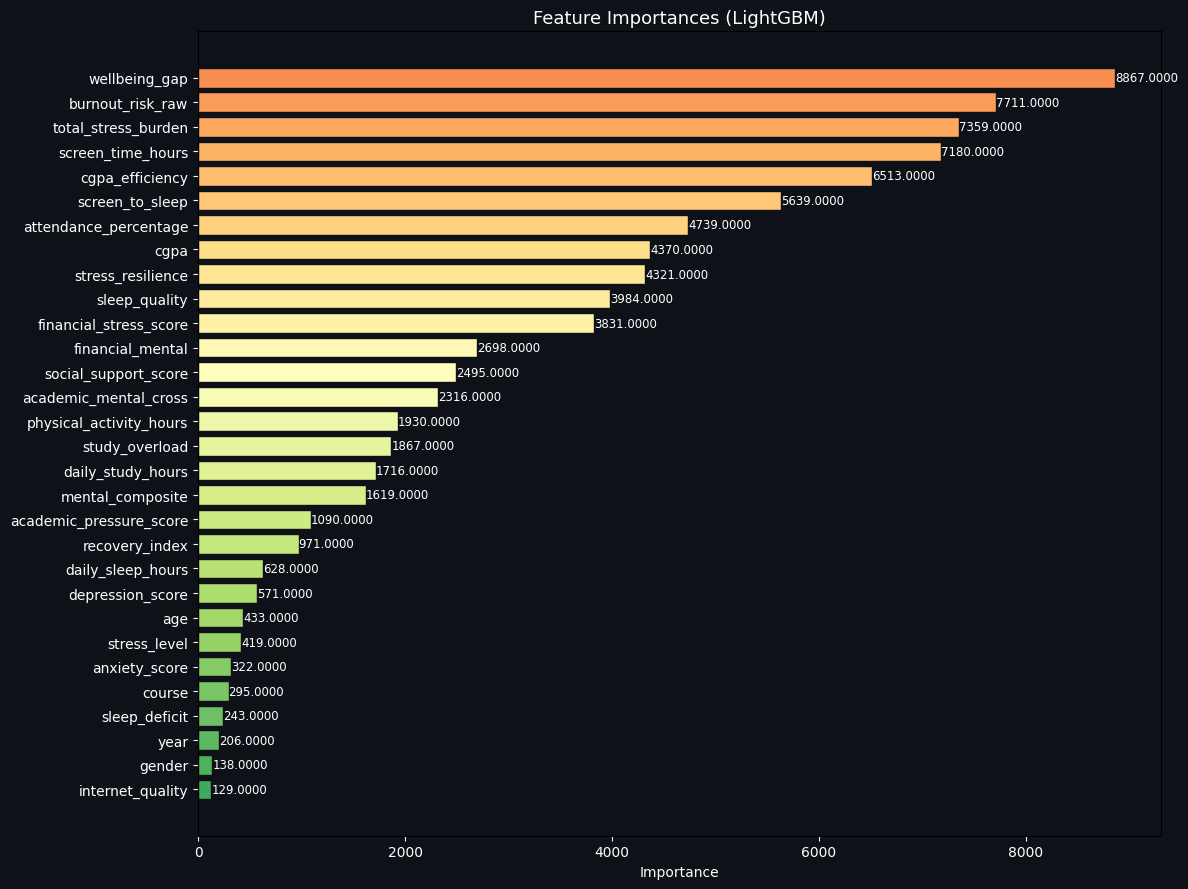

In [ ]:
tree_models = {k: v for k, v in trained.items()
               if hasattr(v, 'feature_importances_')}
best_tree   = max(tree_models, key=lambda k: results[k]['F1 Weighted'])
fi          = pd.Series(trained[best_tree].feature_importances_,
                        index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(DARK); ax.set_facecolor(DARK)

colors_fi = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(fi)))[::-1]
bars = ax.barh(fi.index[::-1], fi.values[::-1], color=colors_fi, edgecolor=DARK)
for b in bars:
    ax.text(b.get_width()+.0005, b.get_y()+b.get_height()/2,
            f'{b.get_width():.4f}', va='center', color='white', fontsize=8.5)

ax.set_title(f'Feature Importances ({best_tree})', color='white', fontsize=13)
ax.set_xlabel('Importance', color='white'); ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=140, bbox_inches='tight', facecolor=DARK)
plt.show()

  All artifacts saved to model_artifacts/
   best_model : Logistic Regression
   test_acc   : 0.9990
   test_f1w   : 0.9990


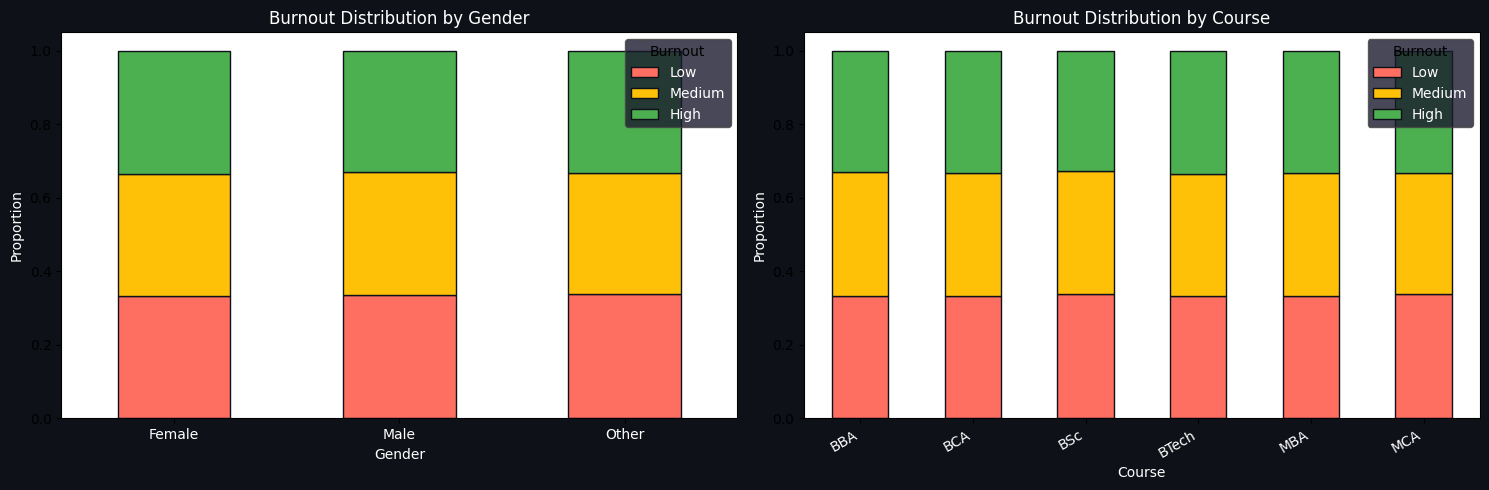

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("model_artifacts", exist_ok=True)

# Define COLORS (assuming these are for plotting, adjust as needed)
COLORS = ['#ff6f61', '#ffc107', '#4CAF50'] # Example colors

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0e1117')

gender_burn = pd.crosstab(df['gender'], df['burnout_level'], normalize='index')
gender_burn = gender_burn.reindex(columns=['Low', 'Medium', 'High'])
gender_burn.plot(kind='bar', stacked=True, ax=axes[0],
                 color=COLORS, edgecolor='#0e1117')
axes[0].set_title('Burnout Distribution by Gender', color='white')
axes[0].set_xlabel('Gender', color='white')
axes[0].set_ylabel('Proportion', color='white')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, color='white')
axes[0].legend(title='Burnout', loc='upper right',
               facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

course_burn = pd.crosstab(df['course'], df['burnout_level'], normalize='index')
course_burn = course_burn.reindex(columns=['Low', 'Medium', 'High'])
course_burn.plot(kind='bar', stacked=True, ax=axes[1],
                 color=COLORS, edgecolor='#0e1117')

# Save best model & scaler
joblib.dump(best_model, "model_artifacts/best_model.pkl")
joblib.dump(scaler,     "model_artifacts/scaler.pkl")

# Save all trained models
for name, model in trained.items():
    joblib.dump(model, f"model_artifacts/{name.replace(' ', '_')}.pkl")

# Save metadata
meta = {
    "feature_columns": FEATURE_COLS,
    "ordinal_maps":    ORDINAL_MAPS,
    "target_map":      TARGET_MAP,
    "target_map_inv":  {str(k): v for k, v in TARGET_MAP_INV.items()},
    "best_model":      best_name,
    "burnout_score_thresholds": {"q33": float(q33), "q66": float(q66)},
    "results":         results,
    "test_metrics": {
        "accuracy":    float(test_acc),
        "f1_weighted": float(test_f1w),
        "f1_macro":    float(test_f1m),
    },
}

with open("model_artifacts/feature_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("  All artifacts saved to model_artifacts/")
print(f"   best_model : {best_name}")
print(f"   test_acc   : {test_acc:.4f}")
print(f"   test_f1w   : {test_f1w:.4f}")
axes[1].set_title('Burnout Distribution by Course', color='white')
axes[1].set_xlabel('Course', color='white')
axes[1].set_ylabel('Proportion', color='white')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', color='white')
axes[1].legend(title='Burnout', loc='upper right',
               facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

plt.tight_layout()
plt.savefig('eda_gender_course.png', dpi=150, bbox_inches='tight',
            facecolor='#0e1117')
plt.show()

In [51]:
# ── Step 1: Install dependencies ────────────────────────────────────────────
!pip install -q streamlit pyngrok

# ── Step 2: Write app.py ─────────────────────────────────────────────────────
APP_CODE = """
import streamlit as st, pandas as pd, numpy as np, joblib, json, os
import matplotlib.pyplot as plt

st.set_page_config(page_title="Student Burnout Predictor",
                   page_icon="🎓", layout="wide")

DARK = '#0e1117'
C3   = ['#22c55e', '#f59e0b', '#ef4444']
ICON = {'Low': '🟢', 'Medium': '🟡', 'High': '🔴'}
MSG  = {
    'Low'   : '✅ Low burnout. Great habits — keep it up!',
    'Medium': '⚡ Moderate burnout. Focus on stress management.',
    'High'  : '🚨 High burnout. Please seek support and reduce workload.',
}

# LabelEncoder encodes alphabetically
GENDER_MAP = {'Female': 0, 'Male': 1, 'Other': 2}
COURSE_MAP = {'BBA': 0, 'BCA': 1, 'BSc': 2, 'BTech': 3, 'MBA': 4, 'MCA': 5}

@st.cache_resource
def load():
    meta  = json.load(open('model_artifacts/feature_meta.json'))
    model = joblib.load('model_artifacts/best_model.pkl')
    sc    = joblib.load('model_artifacts/scaler.pkl')
    return meta, model, sc

meta, model, sc = load()
feat_cols  = meta['feature_columns']
target_inv = meta['target_map_inv']
res        = meta['results']
best_name  = meta['best_model']
test_m     = meta['test_metrics']

with st.sidebar:
    st.markdown("## 🎓 Burnout Predictor")
    st.markdown("---")
    page = st.radio("", ["🔮 Predict", "🏆 Model Results"],
                    label_visibility='collapsed')
    st.markdown("---")
    st.caption(f"Best model: **{best_name}**")
    st.metric("Test Accuracy",      f"{test_m['accuracy']:.4f}")
    st.metric("Test F1 (weighted)", f"{test_m['f1_weighted']:.4f}")

# ── PAGE 1: PREDICT ──────────────────────────────────────────────────────────
if page == "🔮 Predict":
    st.title("🔮 Predict Your Burnout Level")
    c1, c2, c3 = st.columns(3)

    with c1:
        st.subheader("👤 Personal")
        age    = st.slider("Age", 17, 25, 21)
        gender = st.selectbox("Gender", ["Male", "Female", "Other"])
        course = st.selectbox("Course", ["BTech","BCA","BSc","MBA","BBA","MCA"])
        year   = st.selectbox("Year", ["1st","2nd","3rd","4th"])

    with c2:
        st.subheader("📚 Academic")
        study_h    = st.slider("Daily Study Hours", 0.0, 12.0, 5.0, 0.5)
        cgpa       = st.slider("CGPA", 4.0, 10.0, 7.0, 0.1)
        attendance = st.slider("Attendance %", 50.0, 100.0, 75.0, 0.5)
        acad_p     = st.slider("Academic Pressure (1–10)", 1, 10, 5)
        inet_q     = st.selectbox("Internet Quality", ["Poor","Average","Good"])

    with c3:
        st.subheader("🧘 Wellbeing")
        sleep_h  = st.slider("Daily Sleep Hours", 3.0, 10.0, 7.0, 0.5)
        sleep_q  = st.selectbox("Sleep Quality", ["Poor","Average","Good"])
        screen_h = st.slider("Screen Time (hours)", 0.0, 12.0, 4.0, 0.5)
        stress   = st.selectbox("Stress Level", ["Low","Medium","High"])
        anxiety  = st.slider("Anxiety Score (1–10)", 1, 10, 5)
        depress  = st.slider("Depression Score (1–10)", 1, 10, 5)
        fin_s    = st.slider("Financial Stress (1–10)", 1, 10, 5)
        social_s = st.slider("Social Support (1–10)", 1, 10, 5)
        phys_a   = st.slider("Physical Activity (hrs/day)", 0.0, 4.0, 1.0, 0.5)

    if st.button("🚀 Predict My Burnout Level", use_container_width=True):
        om       = meta['ordinal_maps']
        stress_n = om['stress_level'][stress]
        sleep_qn = om['sleep_quality'][sleep_q]
        inet_n   = om['internet_quality'][inet_q]
        year_n   = om['year'][year]

        row = {
            'age'                     : age,
            'gender'                  : GENDER_MAP[gender],
            'course'                  : COURSE_MAP[course],
            'year'                    : year_n,
            'daily_study_hours'       : study_h,
            'daily_sleep_hours'       : sleep_h,
            'screen_time_hours'       : screen_h,
            'stress_level'            : stress_n,
            'anxiety_score'           : anxiety,
            'depression_score'        : depress,
            'academic_pressure_score' : acad_p,
            'financial_stress_score'  : fin_s,
            'social_support_score'    : social_s,
            'physical_activity_hours' : phys_a,
            'sleep_quality'           : sleep_qn,
            'attendance_percentage'   : attendance,
            'cgpa'                    : cgpa,
            'internet_quality'        : inet_n,
        }

        # Engineered features (same as training)
        row['mental_composite']      = anxiety + depress + stress_n * 2
        row['stress_resilience']     = social_s / (stress_n + 1)
        row['sleep_deficit']         = max(0, 8.0 - sleep_h)
        row['study_overload']        = study_h / (sleep_h + 0.5)
        row['academic_mental_cross'] = acad_p * depress
        row['recovery_index']        = phys_a * 2 + sleep_h + social_s * 0.5
        row['burnout_risk_raw']      = anxiety + depress + acad_p
        row['financial_mental']      = fin_s * anxiety
        row['screen_to_sleep']       = screen_h / (sleep_h + 0.1)
        row['cgpa_efficiency']       = cgpa / (study_h + 0.5)
        row['total_stress_burden']   = acad_p + fin_s + stress_n * 3
        row['wellbeing_gap']         = row['mental_composite'] - row['recovery_index']

        Xi       = pd.DataFrame([row])[feat_cols]
        pred_cls = model.predict(Xi)[0]
        proba    = model.predict_proba(Xi)[0]
        label    = target_inv[str(pred_cls)]

        st.markdown("---")
        st.markdown(f"## {ICON[label]}  {label} Burnout  —  confidence: {max(proba)*100:.1f}%")

        fig, ax = plt.subplots(figsize=(8, 3), facecolor=DARK)
        ax.set_facecolor(DARK)
        bars = ax.barh(['Low', 'Medium', 'High'], proba, color=C3, edgecolor=DARK)
        for b in bars:
            ax.text(b.get_width() + .01, b.get_y() + b.get_height() / 2,
                    f'{b.get_width():.1%}', va='center', color='white', fontsize=11)
        ax.set_xlim(0, 1.2)
        ax.tick_params(colors='white')
        ax.set_xlabel('Probability', color='white')
        st.pyplot(fig)

        if   label == 'High':   st.error(MSG[label])
        elif label == 'Medium': st.warning(MSG[label])
        else:                   st.success(MSG[label])

# ── PAGE 2: MODEL RESULTS ────────────────────────────────────────────────────
elif page == "🏆 Model Results":
    st.title("🏆 Model Performance")
    rdf = pd.DataFrame(res).T.sort_values('F1 Weighted', ascending=False)
    st.dataframe(
        rdf.style.background_gradient(
            subset=['Accuracy', 'F1 Weighted', 'F1 Macro'], cmap='RdYlGn'),
        use_container_width=True)
    st.markdown(
        f"**Best:** {best_name} | "
        f"Accuracy: `{test_m['accuracy']:.4f}` | "
        f"F1: `{test_m['f1_weighted']:.4f}`")
    for img in ['confusion_matrices.png', 'feature_importance.png']:
        if os.path.exists(img):
            st.subheader(img.replace('_', ' ').replace('.png', '').title())
            st.image(img, use_column_width=True)
"""

with open('app.py', 'w') as f:
    f.write(APP_CODE)
print("✅  app.py written")

# ── Step 3: Launch Streamlit + ngrok ─────────────────────────────────────────
import subprocess, threading, time
from pyngrok import ngrok
from google.colab import userdata

token = userdata.get('NGROK_AUTH_TOKEN')
if token:
    ngrok.set_auth_token(token)
    print("✅  ngrok token set")
else:
    print("⚠️  Add NGROK_AUTH_TOKEN to Colab Secrets first!")

def _run():
    subprocess.run(["streamlit", "run", "app.py",
                    "--server.port", "8501",
                    "--server.headless", "true"])

t = threading.Thread(target=_run, daemon=True)
t.start()

print("⏳  Waiting for Streamlit to start...")
time.sleep(12)

ngrok.kill()
public_url = ngrok.connect(8501)

print("\n" + "="*55)
print("🎉  App is live!")
print(f"🌐  {public_url}")
print("="*55)
print("⚠️  Keep this cell running — closing Colab stops the app")

✅  app.py written
✅  ngrok token set
⏳  Waiting for Streamlit to start...

🎉  App is live!
🌐  NgrokTunnel: "https://d50a-136-109-26-133.ngrok-free.app" -> "http://localhost:8501"
⚠️  Keep this cell running — closing Colab stops the app
